## Evaluation and comparison of CNN against simple Logistic Regression Model

In [342]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import Sequential, layers

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.model_selection import train_test_split

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [343]:
# data loading
ROOT = Path("./../")
GOOD_DIR = ROOT / "data" / "skins" / "good_cleaned"  # class 0, uncleaned data set /good
BAD_DIR = ROOT / "data" / "skins" / "bad" / "spiderman_cleaned" # class 1, uncleaned dataset: /spiderman
MODEL_PATH = ROOT / "04_Modeling" / "checkpoint.keras"

# image specs
IMG_SIZE = (64, 64)
N_CHANNELS = 4 # RGBA, transparency is important

# data splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# threshold tuning
RECALL_TARGET = 0.95

print(f"Good skins dir: {GOOD_DIR}")
print(f"Bad  skins dir: {BAD_DIR}")
print(f"Image size: {IMG_SIZE}, channels: {N_CHANNELS}")

Good skins dir: ..\data\skins\good_cleaned
Bad  skins dir: ..\data\skins\bad\spiderman_cleaned
Image size: (64, 64), channels: 4


In [344]:
def find_img_paths(good_dir: Path, bad_dir: Path):
    # Iterate over this subtree and yield all existing files (of any kind, including directories) matching the given relative pattern.
    good_paths = sorted(good_dir.glob("*.png"))
    bad_paths  = sorted(bad_dir.rglob("*.png"))

    paths  = good_paths + bad_paths
    labels = [0] * len(good_paths) + [1] * len(bad_paths)

    print(f"Good skins (class 0): {len(good_paths)}")
    print(f"Bad  skins (class 1): {len(bad_paths)}")
    print(f"Total: {len(paths)}")
    print(f"Class ratio bad/good: {len(bad_paths)/len(good_paths):.3f}")
    return paths, labels

all_paths, all_labels = find_img_paths(GOOD_DIR, BAD_DIR)
all_paths_arr = np.array(all_paths, dtype=object)

Good skins (class 0): 9041
Bad  skins (class 1): 959
Total: 10000
Class ratio bad/good: 0.106


In [345]:
def load_images(paths, img_size=(64, 64)):
    imgs = []
    for p in paths:
        # https://keras.io/api/data_loading/image/
        img = tf.keras.utils.load_img(str(p), color_mode="rgba", target_size=img_size)
        arr = tf.keras.utils.img_to_array(img) / 255.0 # normalize to [0, 1]
        imgs.append(arr)
    return np.array(imgs, dtype=np.float32)

print("Loading images")
X = load_images(all_paths)
y = np.array(all_labels, dtype=np.float32)

print(f"X shape: {X.shape}  →  (samples, height, width, channels)")
print(f"y shape: {y.shape}")
print(f"Pixel value range: [{X.min():.2f}, {X.max():.2f}]")

Loading images
X shape: (10000, 64, 64, 4)  →  (samples, height, width, channels)
y shape: (10000,)
Pixel value range: [0.00, 1.00]


## Train / Validation / Test Split

We use a **stratified** split to ensure the class ratio is preserved in all 3 sets.

In [346]:
# split off test set and preserve it for the end
X_trainval, X_test, y_trainval, y_test, paths_trainval, paths_test = train_test_split(
    X, y, all_paths_arr,
    test_size=TEST_SPLIT,
    stratify=y, # preserve class ratio
    random_state=SEED
)

# split training into train + validation
val_relative = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val, paths_train, paths_val= train_test_split(
    X_trainval, y_trainval, paths_trainval,
    test_size=val_relative,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass 1 ratio in train: {y_train.mean():.3f}") # we can just take the mean as we only have two classes
print(f"Class 1 ratio in val: {y_val.mean():.3f}")
print(f"Class 1 ratio in test: {y_test.mean():.3f}")

Train: 7,000 samples (70%)
Val: 1,500 samples (15%)
Test: 1,500 samples (15%)

Class 1 ratio in train: 0.096
Class 1 ratio in val: 0.096
Class 1 ratio in test: 0.096


## Basic Logistic Regression model on PCA-reduced dimensions
Why:
- We try to solve a two class problem and want to optimize a threshold, therefore a log-reg model seems plausible
- PCA will be needed to reduce the 16k pixel-inputs into a useful dimension

In [347]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

Flatten the image data

In [348]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) # take the count of image samples (length) and flatten the rest (-1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [349]:
print(X_train_flat.shape)
print(X_val_flat.shape)
print(X_test_flat.shape)

(7000, 16384)
(1500, 16384)
(1500, 16384)


In [350]:
pca_exploration = PCA(n_components=1000, random_state=SEED)
pca_exploration.fit(X_train_flat)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",1000
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

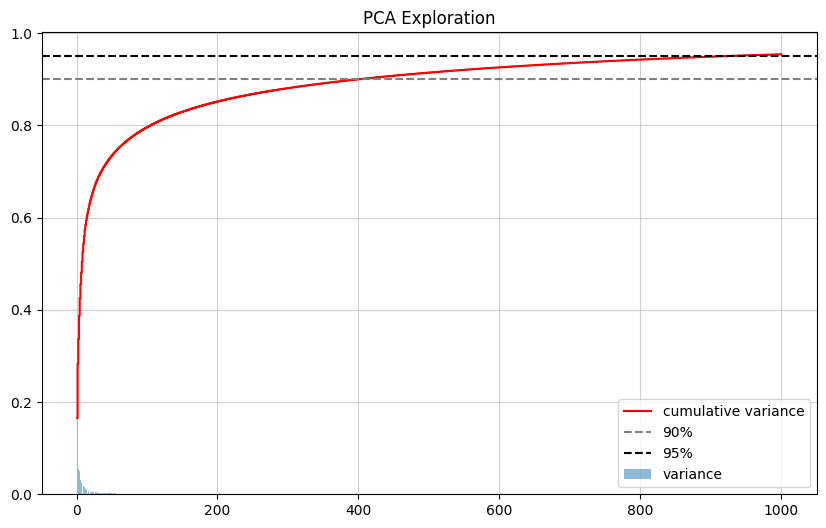

In [351]:
variance_ratio = pca_exploration.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio,  alpha=0.5, align='center', label='variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance,  where='mid', color='red', label='cumulative variance')

plt.axhline(y=0.90, color='gray', linestyle='--', label='90%')
plt.axhline(y=0.95, color='black', linestyle='--', label='95%')
plt.legend()
plt.grid(True, alpha=0.6)
plt.title("PCA Exploration")
plt.show()


Seems like we **need 400 dimensions to explain 90%** of the cumulative variance. **97.5% less dimensions** than before.
- Adjustment: We take even less to prevent overfitting, as we only have 7000 training samples

In [352]:
pca_final = PCA(n_components=50, random_state=SEED)

X_train_pca = pca_final.fit_transform(X_train_flat)

X_val_pca = pca_final.transform(X_val_flat)
X_test_pca = pca_final.transform(X_test_flat)

## Training the LogReg Model
A logistic regression model is trained by iteratively adjusting its numerical weights to maximize the probability of correctly predicting the binary outcomes across a training dataset

In [353]:

param_grid = {
    'solver': ['lbfgs'],
    'C': [0.5, 1.0, 10.0, 100.0], # small values = high regularization
}

In [354]:
logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED)
# Docs: the "balanced" mode uses the values of y to automatically adjust weights inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y)). Thats what we did manually for the CNN

In [355]:
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [356]:
print("start grid search...")
grid_search.fit(X_train_pca, y_train)
print(f"best params: {grid_search.best_params_}")

start grid search...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
best params: {'C': 0.5, 'solver': 'lbfgs'}


In [357]:
best_logreg = grid_search.best_estimator_ # take the best model

In [358]:
metrics = {
    'base': {},
    'cnn': {},
}

In [359]:
model_key = 'base'
y_pred_prob_logreg = best_logreg.predict_proba(X_test_pca)[:, 1]
y_pred_logreg = y_pred_prob_logreg >= 0.5

metrics[model_key]['AUC'] = roc_auc_score(y_test, y_pred_prob_logreg)
metrics[model_key]['PR_AUC'] =  average_precision_score(y_test, y_pred_prob_logreg)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_logreg)
metrics[model_key]['fpr'] = fpr
metrics[model_key]['tpr'] = tpr
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_logreg)
metrics[model_key]['prec'] = prec
metrics[model_key]['rec'] = rec

print(f"AUC: {metrics[model_key]['AUC']:.3f}")
print(f"PR AUC: {metrics[model_key]['PR_AUC']:.3f}")

AUC: 0.942
PR AUC: 0.767


              precision    recall  f1-score   support

      normal       0.98      0.91      0.94      1356
     flagged       0.49      0.84      0.62       144

    accuracy                           0.90      1500
   macro avg       0.73      0.87      0.78      1500
weighted avg       0.93      0.90      0.91      1500



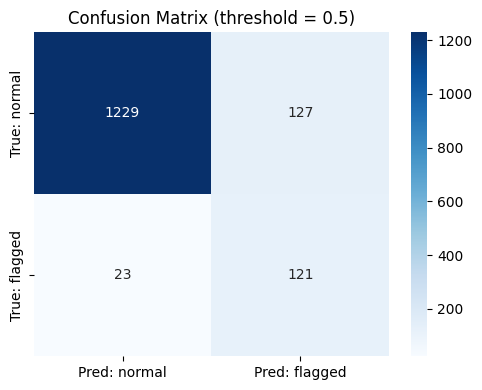

In [360]:

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print(classification_report(y_test, y_pred_logreg, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_logreg, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {0.5})", fontsize=12)
plt.tight_layout()
plt.show()

Accuracy is at 0.93 but the dataset is imbalanced. Reason: the major class seems to outweigh the minority class.

## Threshold tuning, if even possible. We don't know if the model really learned something

In [361]:
# use the validation set (not the test set!) to figure out the max. threshold that allows approx. 95% of recall (5% false negatives) in deployment.
y_pred_VAL_prob_logreg = best_logreg.predict_proba(X_val_pca)[:, 1]

thresholds = np.linspace(0.05, 0.95, 200)
results = []
for t in thresholds:
    y_hat_val = (y_pred_VAL_prob_logreg >= t).astype(int) # prediction / decision boundary
    rec = ((y_hat_val == 1) & (y_val == 1)).sum() / max((y_val == 1).sum(), 1)
    pre = ((y_hat_val == 1) & (y_val == 1)).sum() / max((y_hat_val == 1).sum(), 1)
    f1  = f1_score(y_val, y_hat_val, zero_division=0)
    results.append({"threshold": t, "recall": rec, "precision": pre, "f1": f1, })

results_df = pd.DataFrame(results)

# pick the strictest (highest) threshold that still hits the recall target
target = 0.95
eligible = results_df[results_df["recall"] >= target]
if eligible.empty:
    raise ValueError(f"No threshold reaches recall ≥ {target} on the validation set.")
best_row = eligible.loc[eligible["threshold"].idxmax()]
BEST_THRESH = best_row["threshold"]

print(f"Recall target: ≥ {target}")
print(f"Chosen threshold: {BEST_THRESH:.4f}")
print(f"Recall: {best_row['recall']:.4f}")
print(f"precision: {best_row['precision']:.4f}")
print(f"F1: {best_row['f1']:.4f}")

Recall target: ≥ 0.95
Chosen threshold: 0.1043
Recall: 0.9514
precision: 0.2408
F1: 0.3843


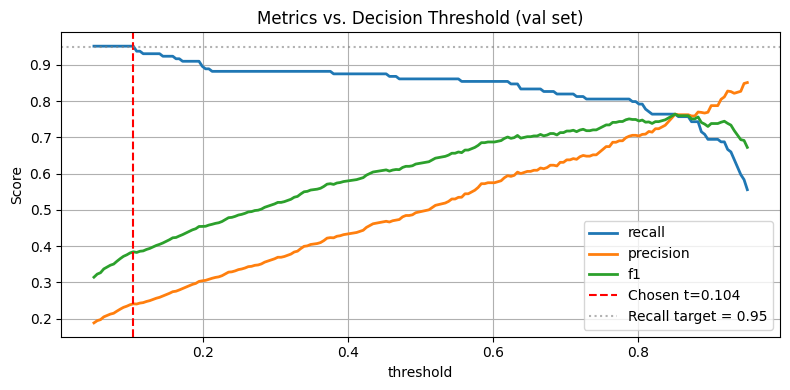

In [362]:
ax = results_df.set_index("threshold")[["recall", "precision", "f1"]].plot(
    figsize=(8, 4), linewidth=2, grid=True
)
ax.axvline(BEST_THRESH, color="red", linestyle="--", label=f"Chosen t={BEST_THRESH:.3f}")
ax.axhline(RECALL_TARGET, color="gray", linestyle=":", alpha=0.6, label=f"Recall target = {RECALL_TARGET}")
ax.set_title("Metrics vs. Decision Threshold (val set)")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

does not look good. We can't even reach our recall target of 0.95

Final Test Evaluation (threshold = 0.1042713567839196)
              precision    recall  f1-score   support

      normal       0.99      0.68      0.81      1356
     flagged       0.24      0.94      0.38       144

    accuracy                           0.71      1500
   macro avg       0.62      0.81      0.60      1500
weighted avg       0.92      0.71      0.77      1500



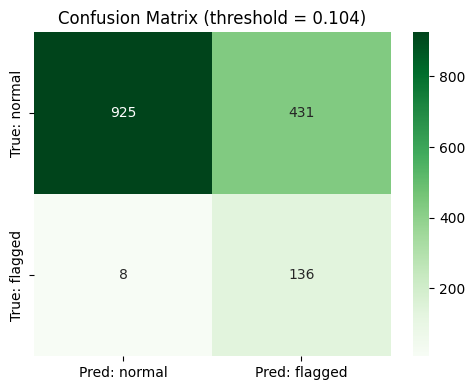

In [363]:
# Final evaluation on TEST set with tuned threshold
y_pred_tuned = (y_pred_prob_logreg >= BEST_THRESH).astype(int)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(f"Final Test Evaluation (threshold = {BEST_THRESH})")
print(classification_report(y_test, y_pred_tuned, target_names=["normal", "flagged"]))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_tuned, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Pred: normal", "Pred: flagged"],
    yticklabels=["True: normal", "True: flagged"],
    ax=ax
)
ax.set_title(f"Confusion Matrix (threshold = {BEST_THRESH:.3f})", fontsize=12)
plt.tight_layout()
plt.show()

Confusion matrix for same 0.95 recall target and testing data from a CNN:

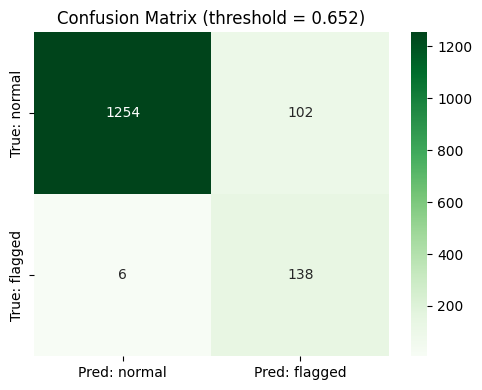

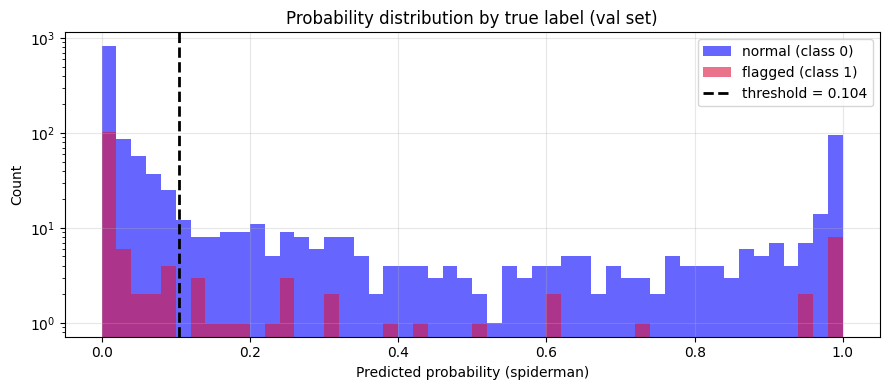

In [364]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_prob_val[y_val == 0], bins=50, range=(0, 1),alpha=0.6, label="normal (class 0)", color="blue")
ax.hist(y_prob_val[y_val == 1], bins=50, range=(0, 1),alpha=0.6, label="flagged (class 1)", color="crimson")

ax.axvline(BEST_THRESH, color="black", linestyle="--", linewidth=2, label=f"threshold = {BEST_THRESH:.3f}")

ax.set_xlabel("Predicted probability (spiderman)")
ax.set_ylabel("Count")
ax.set_title("Probability distribution by true label (val set)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The base model didn't quite learn the patterns. The curves should show this later

## CNN Inference on Test Set

In [365]:
# RandomColorShift class definition needed because that layer wasn't saved into the keras file in the modeling...

from keras.saving import register_keras_serializable

class RandomColorShift(layers.Layer):
    def __init__(self, shift_val=0.1, **kwargs):
        super().__init__(**kwargs)
        self.shift_val = shift_val

    def call(self, x, training=None):
        if not training:
            return x  # passthrough at inference
        rgb = x[..., :3]  # mask the R, G, B Values from x
        alpha = x[..., 3:4]  # mask alpha, dont change it
        noise = tf.random.uniform(tf.shape(rgb), -self.shift_val, self.shift_val)
        return tf.concat([tf.clip_by_value(rgb + noise, 0.0, 1.0), alpha], axis=-1)  # put data with noise together

    def get_config(self):
        config = super().get_config()
        config.update({
            "shift_val": self.shift_val
        })
        return config


data_augmentation = tf.keras.Sequential([
    RandomColorShift(0.1),
    layers.GaussianNoise(0.05),  # already respects training flag
])

In [366]:
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={"Custom>RandomColorShift": RandomColorShift})

In [367]:
OPTIMAL_THRESHOLD = 0.652 # already obtained from modeling
y_pred_prob_cnn = model.predict(X_test).ravel()
y_pred_cnn = (y_pred_prob_cnn >= OPTIMAL_THRESHOLD).astype(int)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [368]:
model_key = 'cnn'

metrics[model_key]['AUC'] = roc_auc_score(y_test, y_pred_prob_cnn)
metrics[model_key]['PR_AUC'] = average_precision_score(y_test, y_pred_prob_cnn)

fpr, tpr, _ = roc_curve(y_test, y_pred_prob_cnn)
metrics[model_key]['fpr'] = fpr
metrics[model_key]['tpr'] = tpr
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob_cnn)
metrics[model_key]['prec'] = prec
metrics[model_key]['rec'] = rec

print(f"AUC: {metrics[model_key]['AUC']:.3f}")
print(f"PR AUC: {metrics[model_key]['PR_AUC']:.3f}")

AUC: 0.983
PR AUC: 0.915


# ROC and Precision-Recall Curves

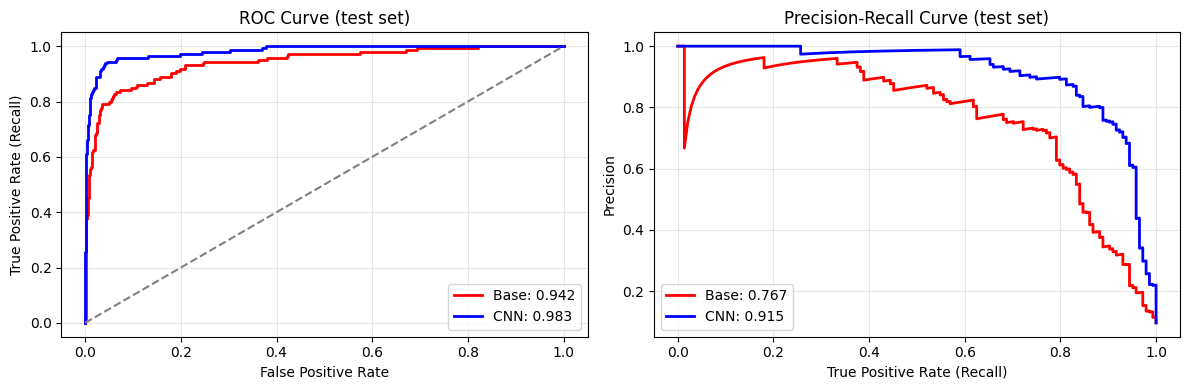

In [369]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(metrics['base']['fpr'], metrics['base']['tpr'], linewidth=2, color="red", label=f"Base: {metrics['base']['AUC']:.3f}")
axes[0].plot(metrics['cnn']['fpr'], metrics['cnn']['tpr'], linewidth=2, color="blue", label=f"CNN: {metrics['cnn']['AUC']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve (test set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics['base']['rec'], metrics['base']['prec'], linewidth=2, color="red", label=f"Base: {metrics['base']['PR_AUC']:.3f}")
axes[1].plot(metrics['cnn']['rec'], metrics['cnn']['prec'], linewidth=2, color="blue", label=f"CNN: {metrics['cnn']['PR_AUC']:.3f}")
axes[1].set_xlabel("True Positive Rate (Recall)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (test set)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion & Deployment Recommendation

Our primary constraint was isolating anomalous skins with a recall of $\ge 0.95$.

* **The Precision-Recall Tradeoff:** Forcing the PCA-LogReg baseline to our recall target (with a threshold $0.10$) dropped its precision down to ~24%.
* The CNN successfully classified one minecraft skin class from normal 'noise", retaining a 65% precision at 95% recall.

### Noise (FPR) Reduction:
The CNN reduces false-positive moderation from 431 down to 102, that's a **76.33% reduction**!
$$FPR_{base, 0.104}= \frac{FP}{FP + TN}= \frac{431}{431 + 925} = \frac{431}{1356} \approx \mathbf{31,78 \%}$$ Every third normal player is suspicious. Very high!
$$FPR_{CNN, 0.652}=\frac{102}{102 + 1254} = \frac{102}{1356} \approx \mathbf{7,52 \%}$$


### Precision (Accuracy of Flags) Improvement:

The CNN improves the ratio of correctly flagged players from 136 out of 567 up to 138 out of 240, that's a **139.68% relative increase**!


$$Precision_{base, 0.104}= \frac{TP}{TP + FP} = \frac{136}{136 + 431} = \frac{136}{567} \approx \mathbf{23,99 \%}$$

 More than three out of four flagged players are innocent. Very inefficient!


$$Precision_{CNN, 0.652}=\frac{138}{138 + 102} = \frac{138}{240} \approx \mathbf{57,50 \%}$$

**Deployment Decision: DEPLOY (als Human-in-the-Loop Filter, Warning System)**
> TODO: before release: Train on actual prohibited classes e.g. nsfw skins (out of this academic scope)

**Deployment Strategy:**
Given the residual false-positive rate, executing automated bans remains unviable. We recommend deploying the CNN strictly as a pre-filter system. Normal only flagged players for manual review by a moderation team. Threshold can also be adjusted for lower recall and less FP, leaving this also up to the server administration